In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df = df.drop(columns=['deck'])

In [4]:
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)
df.head()

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,Third,man,True,Southampton,no,False,True,False,True
1,1,1,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False,False,False,False
2,1,3,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True,False,False,True
3,1,1,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False,False,False,True
4,0,3,35.0,0,0,8.0500,Third,man,True,Southampton,no,True,True,False,True


In [5]:
X = df[['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male']]
y = df['survived']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [8]:
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(accuracy)

0.8100558659217877


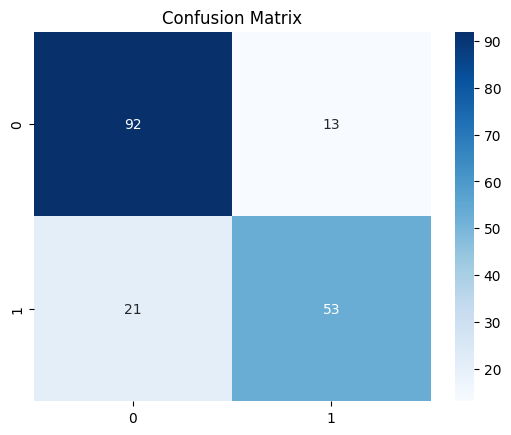

In [9]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Confusion matrix batata hai model ne kitne passengers sahi predict kiye aur kitne mein galti hui. Diagonal (upar-left se neeche-right) wale numbers "sahi predictions" hain, aur baaki do numbers "galat predictions" (jaise kisi ko survive kaha jo actually nahi bacha, ya ulta). Zyada tar numbers diagonal pe hain, jo yeh dikhata hai ke model 81% accuracy ke saath achi tarah perform kar raha hai.